## Background

**Dataset:** `sklearn.datasets.make_moons`

`make_moons` is a synthetic dataset from `sklearn` that generates a **two-class, two-dimensional** dataset shaped like two half-circles. Because the boundary between classes is curved, **no linear decision boundary can cleanly separate them**. In this lab, we will compare the three different SVM Kernels to see which performs best.



## Step 1: Setup: Load Libraries and Generate Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              RocCurveDisplay, ConfusionMatrixDisplay, confusion_matrix)

Class distribution:
1    1000
0    1000
Name: count, dtype: int64


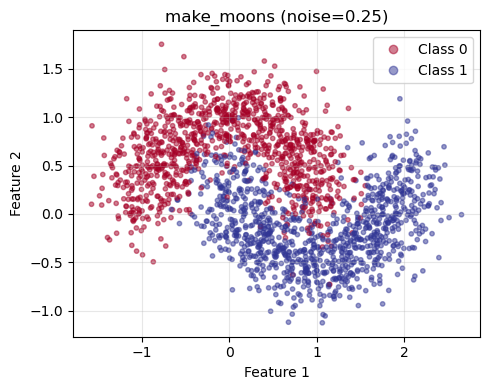

In [2]:

# The `noise` parameter adds Gaussian noise to the coordinates
# Higher noise blurs the boundary and makes the problem harder
# Too little noise makes it trivial

X, y = make_moons(n_samples=2000, noise=0.25, random_state=42)

print(f"Class distribution:\n{pd.Series(y).value_counts()}")

fig, ax = plt.subplots(figsize=(5, 4))
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10, alpha=0.5)
handles, _ = scatter.legend_elements()
ax.legend(handles, ['Class 0', 'Class 1'])
ax.set_title('make_moons (noise=0.25)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The dataset has two features and two balanced classes:

| Feature | Description |
|---------|-------------|
| `X[:, 0]` | x-coordinate (with noise) |
| `X[:, 1]` | y-coordinate (with noise) |



## Step 2: Preprocessing

SVMs are scale-variant, so we always apply `StandardScaler` before fitting. Split your data using `train_test_split` with a test_size of 0.3,  `random_state = 42`, and `stratify = y`. 

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42,
                                                   stratify = y)

In [4]:
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(1400, 2)
(600, 2)


In [6]:
# svm(kernel)

---

## Background: Support Vector Classifier

The **support vector classifier** (SVC) fits a linear decision boundary by maximizing the margin between classes while allowing some observations to violate it. The penalty hyperparameter `C` controls how harshly violations are penalized:

- **Large C**( 100 to 1000): violations penalized heavily → narrow margin, fewer support vectors, tighter fit to training data
- **Small C** ( 0.0001 to 1): violations tolerated → wide margin, more support vectors, smoother boundary

## Step 3: Tune a Linear SVM with GridSearchCV

---

Use `GridSearchCV` with 5-fold cross-validation, search over the following values of `C` to find the best linear kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: .001, .01, 0.1, 1, 10, 100



In [7]:
#SVC(kernel = '')

C = {"C":[.001, .01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    SVC(kernel = 'linear'),
    C,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters:  {grid_search.best_params_}")

print(f"CV Accuracy: {grid_search.best_score_:.3f}")

lin_best = grid_search.best_estimator_
lin_acc = accuracy_score(y_test, lin_best.predict(X_test_scaled))


print(f"Test accuracy:    {lin_acc:.3f}")

Best parameters:  {'C': 1}
CV Accuracy: 0.860
Test accuracy:    0.880


##### Look at the accuracy each value of C yielded in `grid_linear`. Hint: You can access the cross validation results using `.cv_results`, then select only the `param_C` and `mean_test_score` column. Convert these results into a DataFrame for easier interpretation!

In [8]:
param_c = grid_search.cv_results_['param_C']
mean_test_score = grid_search.cv_results_['mean_test_score']

pd.DataFrame({'Parameters':param_c, 'Test Accuracy': mean_test_score})

,Parameters,Test Accuracy
0,0.001,0.847143
1,0.01,0.853571
2,0.1,0.856429
3,1,0.860000
4,10,0.860000
5,100,0.860000


> **Q1: What `C` value did cross-validation select? Given that the moons boundary is curved, did you expect the linear kernel to achieve strong accuracy regardless of `C`? At what value of C does the accuracy stop improving?**

CV selected a value of 1 for `C`. Nope! We did not expect the lienar kernel to achieve a strong accuracy due to the distribution of the data not following a linear pattern. Accuracy stops improving at the value of 1. 

---

## Background: RBF Kernel

When the true decision boundary is non-linear, we replace the inner product in the SVC formulation with a **kernel function** that implicitly maps observations into a higher-dimensional space. The **radial basis function (RBF)** kernel measures similarity by distance:

$$K(x_i, x_j) = \exp\!\left(-\gamma \|x_i - x_j\|^2\right)$$

The hyperparameter $\gamma$ controls how quickly influence decays with distance:

- **Large $\gamma$** → complex, local boundary (high variance risk)
- **Small $\gamma$** → smooth, global boundary (high bias risk)

Both `C` and `gamma` need to be tuned jointly via cross-validation.

## Step 4: Tune an RBF SVM with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`,search over the following values of `C`,and `gamma` to find the best polynomial kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: 0.1, 1, 10, 100
`gamma`: `scale`, 0.001, 0.01, 0.1, 1, 10

In [9]:
param_grid = {"C": [.01, 1, 10, 100],
        "gamma": ["scale", .001, .01, .1, 1, 10]}

grid_search = GridSearchCV(
    SVC(kernel = 'rbf', random_state = 42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters:  {grid_search.best_params_}")

print(f"CV Accuracy: {grid_search.best_score_:.3f}")

rbf_best = grid_search.best_estimator_
rbf_acc = accuracy_score(y_test, rbf_best.predict(X_test_scaled))


print(f"Test accuracy:    {rbf_acc:.3f}")

Best parameters:  {'C': 1, 'gamma': 1}
CV Accuracy: 0.948
Test accuracy:    0.938


> **Q2: How much does the RBF kernel improve over the linear SVM? Do the best `C` and `gamma` values suggest a smooth or tightly-fitted boundary?**

The test accuracy improves from .860 to .938, so a .078 increase. Also, the best gamma value was 'scale'. This suggests that the boundary is fitting more smooth fitting boundary, since gamma = scale avoids overfitting.  

---

## Background: Polynomial Kernel

The **polynomial kernel** of degree $d$ is:

$$K(x_i, x_j) = ( \gamma \langle x_i, x_j \rangle + r)^d$$


Higher degree allows the boundary to curve more, capturing complex feature interactions, but also increases the risk of overfitting. The `coef0` term (r in the formula above) weights the influence of lower-degree polynomial terms.

## Step 5: Tune a Polynomial SVM with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the following values of `C`, `degree`, and `coef0` to find the best polynomial kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: 0.1, 1, 10, 100
`gamma`: 'scale', 0.001, 0.01, 0.1, 1
`degree`: 2, 3, 4
`coef0`: 0.0, 1.0

In [10]:
param_grid = {"C": [.1, 1, 10, 100],
        "gamma": ["scale", .001, .01, .1, 1],
             "degree": [2, 3, 4],
             "coef0": [0, 1]}

grid_search = GridSearchCV(
    SVC(kernel = 'poly', random_state = 42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters:  {grid_search.best_params_}")

print(f"CV Accuracy: {grid_search.best_score_:.3f}")

poly_best = grid_search.best_estimator_
poly_acc = accuracy_score(y_test, poly_best.predict(X_test_scaled))


print(f"Test accuracy:    {poly_acc:.3f}")

Best parameters:  {'C': 1, 'coef0': 1, 'degree': 3, 'gamma': 1}
CV Accuracy: 0.945
Test accuracy:    0.940


> **Q3: Which degree polynomial did GridSearchCV select? How does the polynomial kernel's accuracy compare to the RBF kernel for this crescent-shaped data? Does a higher degree always help, and why or why not?**

It selected the third degree polynomial, it is essentially the same, with a .001 decrease. I think a higher degree will not always help, depending on how complex the model ends up being, as you could start overfitting. RBF kernels are naturally smoother, and would work well with the curved boundaries in the plot above, which is likely why the accuracy stayed was similar with this model. 

---

## Step 6: Streamlining the Hyperparameter Search

Rather than selecting a kernel first and tuning it separately, we can treat the kernel type itself as a hyperparameter. `GridSearchCV` accepts a list of parameter grids, letting each kernel specify its own relevant parameters in a single joint search. Create a joint search where each search grid we used above is included as a dictionary item, with its specified kernel included. `param_grid_all` should be a list of three dictionaries. Then, Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the parameter grid you created to find the best configuration. Report the best parameters, CV accuracy, and test accuracy.

In [11]:
param_grid_all = [
    {
         'kernel': ['linear'],
            'C': [ .1, 1, 10, 100]
    },
    {
        'kernel': ['rbf'],
        'gamma':['scale', .001, .01, .1, 1, 10],
        'C': [0.1, 1, 10, 100]
    },
    {
         'kernel': ['poly'],
         'C': [0.1, 1, 10, 100],
         'gamma':['scale', .001, .01, .1, 1],
         'degree': [2, 3, 4],
         'coef0': [0,1]
    }
]

grid_overall = GridSearchCV(
    SVC(random_state = 42),
    param_grid = param_grid_all,
    cv = 5, 
    scoring = 'accuracy',
    n_jobs = -1
)
grid_overall.fit(X_train_scaled, y_train)

best_overall = grid_overall.best_estimator_

test_acc_overall = accuracy_score(y_test, best_overall.predict(X_test_scaled))

print(f"Best params: {grid_overall.best_params_}")
print(f"CV Accuracy: {grid_overall.best_score_:.3f}")

print(f"Test Accuracy: {test_acc_overall:.3f}")

Best params: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
CV Accuracy: 0.948
Test Accuracy: 0.938


> **Q4: Which kernel did the overall search select as best? Is this consistent with the cross validation accuracy from the individual kernel results? Given the curved, crescent-shaped structure of the moons data, does the winning kernel make intuitive sense?**

the best kernel was RBF, and is consistent with the cv accuracy tests individually. Yes, since a crescent is a rounded smooth shape, an RBF kernel will fit great

---


## Step 7: Tune a Random Forest with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the following values of `n_estimators`, `max_depth`, and `min_samples_leaf` to find the best random forest configuration. Report the best parameters, CV accuracy, and test accuracy.

`n_estimators`: 100, 200
`max_depth` : None, 5, 10
`min_samples_leaf`: 1, 5, 10

In [12]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state = 42),
    param_grid_rf,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1
)

grid_rf.fit(X_train_scaled, y_train)

best_rf = grid_rf.best_estimator_
test_acc_rf = accuracy_score(y_test, best_rf.predict(X_test_scaled))

print(f"Best params: {grid_rf.best_params_}")
print(f"CV Accuracy: {grid_rf.best_score_:.3f}")

print(f"Test Accuracy: {test_acc_rf:.3f}")

Best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 100}
CV Accuracy: 0.946
Test Accuracy: 0.938


> **Q5:  How does the Random Forest test accuracy compare to the best SVM kernel?**

It performed well with just a .012 less accurate CV result, and an almost identical Test accuracy. Essentially identical results, interesting to see how random tree which uses branch splits came to a such a similar result with RBF that uses smooth boundaries.

---

## Step 8: Visualize Decision Boundaries

Because `make_moons` has only two features, we can plot the full decision region for all four models. This is where the differences between kernels and the tree-based approach become visually obvious. Create four visualizations of the decision boundaries for each model above. Use  `DecisionBoundaryDisplay.from_estimator()` to create the visualizations. Add a title specifying the model/kernel used to each plot. 

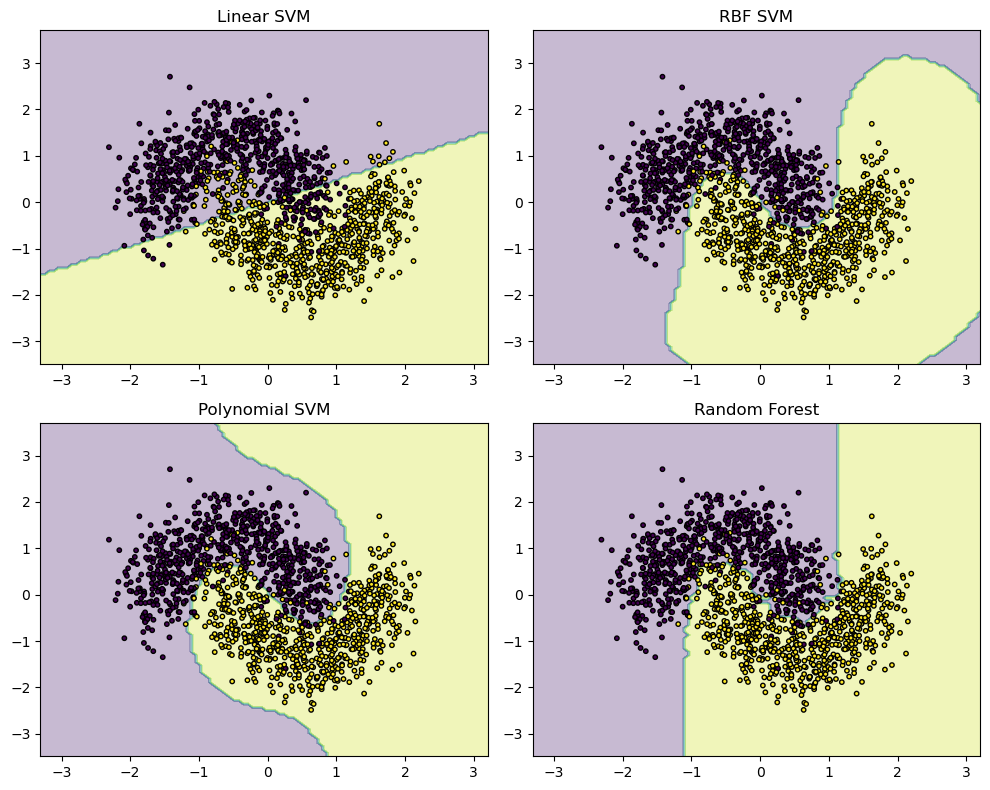

In [13]:
models = [
    (lin_best, 'Linear SVM'),
    (rbf_best, 'RBF SVM'),
    (poly_best, 'Polynomial SVM'),
    (best_rf, 'Random Forest')
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (model, title) in zip(axes.flatten(), models):
    DecisionBoundaryDisplay.from_estimator(model, X_train_scaled, ax=ax, response_method="predict", alpha=0.3)
    ax.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, s=10, edgecolors='k')
    ax.set_title(title)

plt.tight_layout()
plt.show()

> **Q6: How does the linear kernel's decision boundary compare visually to the RBF, polynomial, and Random Forest boundaries? How does the Random Forest boundary differ from the SVM boundaries?**

The linear boundary is essentially a straight divison across the middle of the plot, while the other three have better fit with rounded edges to fit the points better. It fits poorly because of a linear model's nature and inability to change the slope to better fit the points. The Random Forest is somewhat similar to the SVM boundaries, but take a much more stepped, or definite, shape because of the conditional and binary states of the decision tree matrix. 

---

## Step 9: Model Comparison


### Confusion Matrices 

Accuracy alone can hide where models differ in their error patterns. Confusion matrices break down false positives and false negatives. 

##### Create a confusion matrix for each of the four models above. 

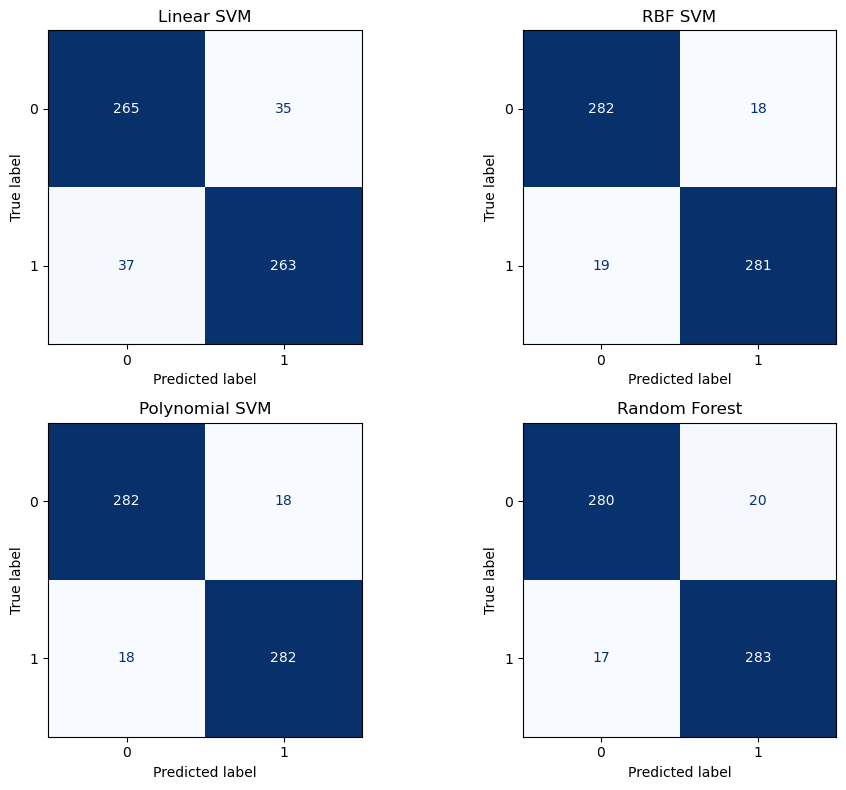

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (model, title) in zip(axes.flatten(), models):
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.tight_layout()
plt.show()

>**Q7:Comment on the results of the confusion matrices. Did all four models have similar misclassifications?**

Linear had the highest number of misclassifications, with 35 and 37 false positive and false negatives respectively. RBF, Polynomial and Random Forest all were very close, with all being withing 2 or 3 false predictions of eachother. Polynomial SVM did have the smallest sum of misclassifications, and an balanced number of false positive and false negative. 

### ROC Curves

The **ROC (Receiver Operating Characteristic)** curve plots the true positive rate against the false positive rate as the classification threshold varies. A random classifier follows the diagonal (AUC = 0.50); a perfect classifier has AUC = 1.0.

**AUC (Area Under the Curve)** summarizes the entire ROC curve in a single number that makes it easy to compare different models.

**How ROC works for SVMs specifically:**
Unlike logistic regression, a standard SVC does not output class probabilities. Instead, it computes a decision function — the signed distance of each observation from the decision boundary. Points far on the positive side get large positive scores; points far on the negative side get large negative scores. `RocCurveDisplay.from_estimator` uses this decision function to build the ROC curve.

This means the ROC curve reflects how well each kernel's decision function ranks observations, independent of where the hard boundary is drawn.

##### Plot the ROC Curves for each of the four models on the same plot. Add a line indicating a random classifier (ACU = 0.5) and a legend. 


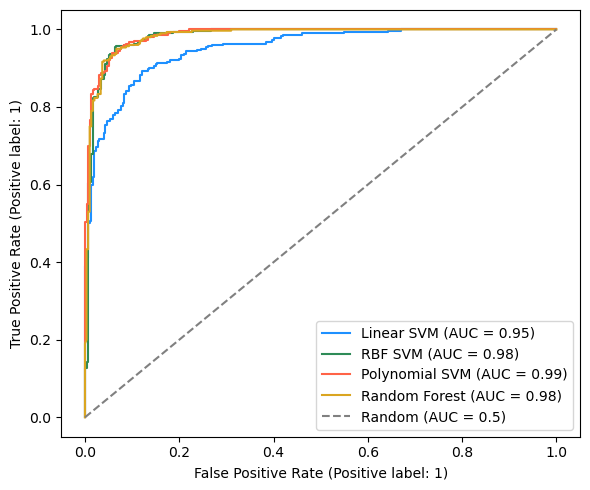

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_estimator(lin_best, X_test_scaled, y_test, name="Linear SVM", ax=ax, color="DodgerBlue")
RocCurveDisplay.from_estimator(rbf_best, X_test_scaled, y_test, name="RBF SVM", ax=ax, color="SeaGreen")
RocCurveDisplay.from_estimator(poly_best, X_test_scaled, y_test, name="Polynomial SVM", ax=ax, color="Tomato")
RocCurveDisplay.from_estimator(best_rf, X_test_scaled, y_test, name="Random Forest", ax=ax, color="Goldenrod")

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random (AUC = 0.5)')
ax.legend()
plt.tight_layout()
plt.show()

> **Q8: Do the AUC values align with what you observed in the confusion matrices and accuracy scores? How does the Random Forest compare to the SVM kernels across all three metrics? Considering accuracy, AUC, and the decision boundary shape, which model would you choose for this dataset and why?**

Yes, all four models had the vast majority of their predictions come out correctly, with the ratio of correct predictions matching the AUC for the four models. The Random Forest performed as well as the best two SVMs, Polynomial and RBF. Given the nearly as strong accuracy, as well as the shape of the decision boundary I would go with the RBF SVM, as I think the flexibility allowed in the model most accurately matches the shape of data points in the actual cloud. 

>**Q9: In terms of overall perforamnce, why does the linear kernel not perform as well as the RBF kernel, Polynomial Kernel, or Random Forest. What is a difference between these latter three models and the former that impacts the shape of the decision boundary and overall accuracy.**

The Linear Model performs worse due to the nature of only having a single slope to work with when classifying data points. When you have a highly mixed set of data that needs clasification in different groups, having a more flexible system is a better fit. The other three models performed better in capturing the non-linearity of the data.  